The goal of this project is to predict the age of abalone from their physical characteristics (length, diameter, weight, etc.) in order to avoid the long and tedious process of counting under a microscope. I will use descriptive statistics and visualizations to identify trends, then a regression model to predict the age.

### Pseudocode
```
1. START
2. LOAD abalone.data
3. CLEAN DATA:
   - Encode 'Sex' (One-Hot)
   - Check for missing values
4. EXPLORE DATA:
   - Calculate descriptive statistics
   - Plot histogram of Rings
   - Plot correlation heatmap
5. TRAIN MODEL:
   - Split data into train/test (80/20)
   - Normalize features
   - Train Linear Regression
6. EVALUATE MODEL:
   - Calculate MSE and R²
7. END
```

First 5 rows:
   Sex  Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell weight  Rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  

Missing values:
 Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

Descriptive statistics:
             Length     Diameter       Height  Whole weight  Shucked weight  \
count  4177.000000  4177.000000  

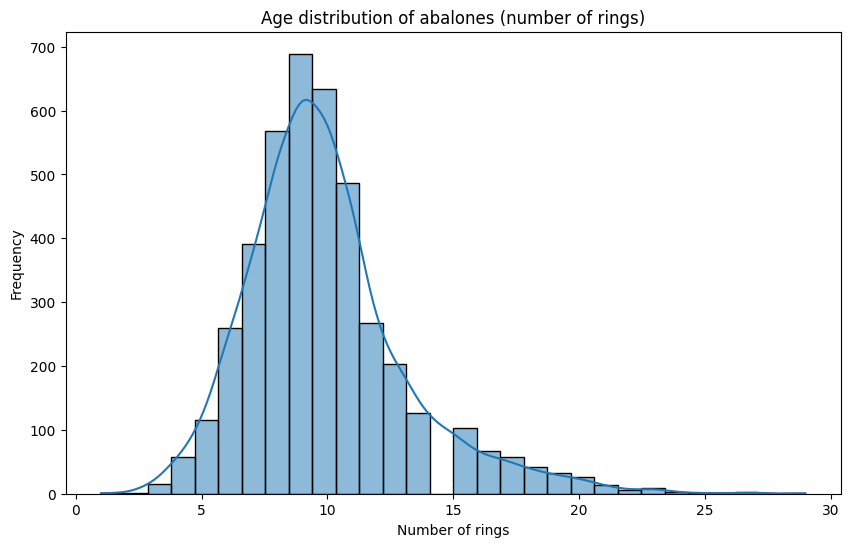

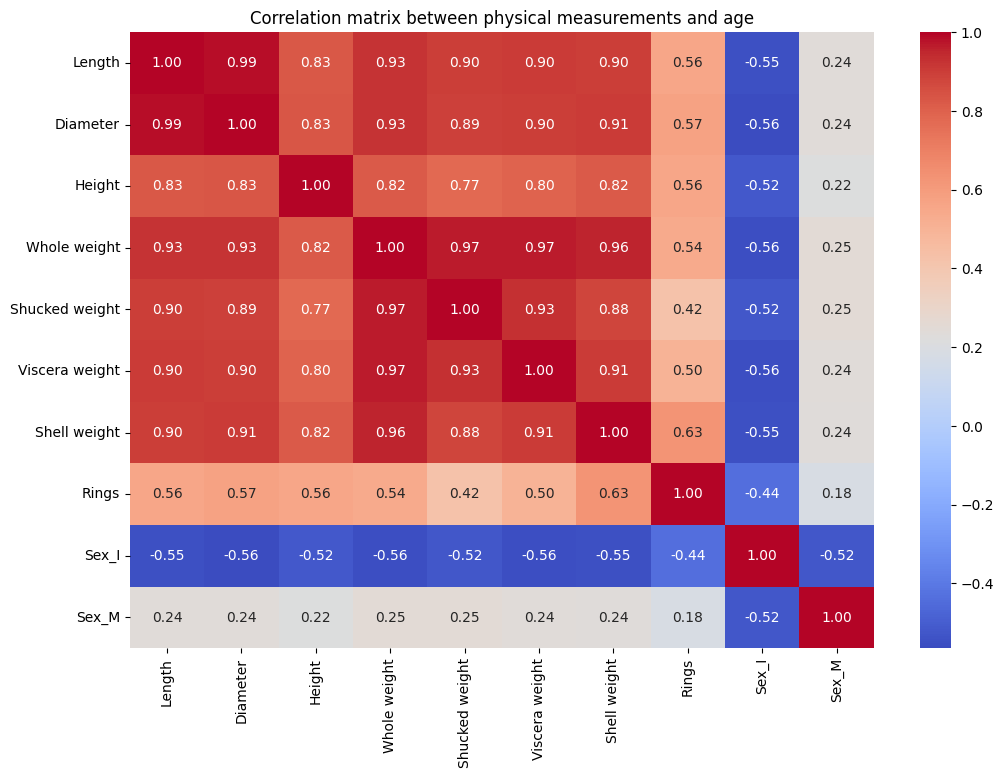


Top correlations with Rings:
 Rings             1.000000
Shell weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Whole weight      0.540390
Viscera weight    0.503819
Shucked weight    0.420884
Sex_M             0.181831
Sex_I            -0.436063
Name: Rings, dtype: float64


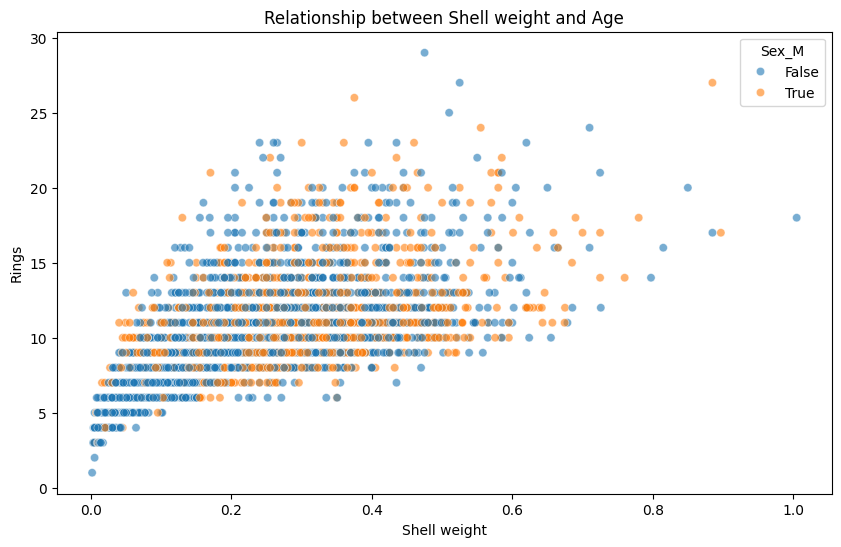


Model Evaluation - MSE: 4.89, R²: 0.55
The model explains more than 50% of the variance in Rings (good fit).


In [19]:
# Goal: Predict abalone age (Rings) from physical measurements to avoid manual counting under a microscope.

# 1. Load the Abalone dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load the data
data = pd.read_csv("abalone.data", header=None)
columns = ["Sex", "Length", "Diameter", "Height", "Whole weight", "Shucked weight", "Viscera weight", "Shell weight", "Rings"]
data.columns = columns

# Display the first 5 rows
print("First 5 rows:\n", data.head())

# 2. Clean the data
# Check for missing values
print("\nMissing values:\n", data.isnull().sum())

# One-Hot Encoding for 'Sex'
data = pd.get_dummies(data, columns=["Sex"], drop_first=True)

# 3. Descriptive statistics
print("\nDescriptive statistics:\n", data.describe())

# 4. Create visualizations
# a. Age distribution (Rings)
plt.figure(figsize=(10, 6))
sns.histplot(data["Rings"], bins=30, kde=True)
plt.title("Age distribution of abalones (number of rings)")
plt.xlabel("Number of rings")
plt.ylabel("Frequency")
plt.show()

# b. Correlation matrix
plt.figure(figsize=(12, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix between physical measurements and age")
plt.show()

# Top correlations with Rings
print("\nTop correlations with Rings:\n", corr["Rings"].sort_values(ascending=False))

# c. Scatter plot: Relationship between Shell weight and age (strongest correlation)
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Shell weight", y="Rings", data=data, hue="Sex_M", alpha=0.6)
plt.title("Relationship between Shell weight and Age")
plt.show()

# 5. Train a linear regression model
# Split variables
X = data.drop("Rings", axis=1)
y = data["Rings"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# 6. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Evaluation - MSE: {mse:.2f}, R²: {r2:.2f}")

# Interpretation
if r2 > 0.5:
    print("The model explains more than 50% of the variance in Rings (good fit).")
else:
    print(" The model has low explanatory power. Consider adding polynomial features or trying a different model.")